In [97]:
import matplotlib.pyplot as plt
import numpy as np
import scipy 

In [98]:
# Beam 
# post_target_beam = np.loadtxt("postTarget_beam.dat", dtype = str, delimiter=",").astype(float)
# post_degrader1_beam = np.loadtxt("postDegrader1_beam.dat", dtype = str, delimiter=",").astype(float)
# post_target_beam_10pt95 = np.loadtxt("postTarget_beam_10.95MeV.dat", dtype = str, delimiter=",").astype(float)
# post_degrader1_beam_10pt95 = np.loadtxt("postDegrader1_beam_10.95MeV.dat", dtype = str, delimiter=",").astype(float)
# post_target_beam_6 = np.loadtxt("postTarget_beam_6MeV.dat", dtype = str, delimiter=",").astype(float)

# Recoil 
post_target_reaction = np.loadtxt("postTarget_reaction.dat", dtype = str, delimiter=",").astype(float)
# post_target_reaction_10pt95 = np.loadtxt("postTarget_reaction_10.95MeV.dat", dtype = str, delimiter=",").astype(float)
# post_target_reaction_6 = np.loadtxt("postTarget_reaction_6MeV.dat", dtype = str, delimiter=",").astype(float)
# fp_rec = np.loadtxt("fp_reaction.dat",dtype = str, delimiter=",").astype(float)
# fp_rec_10pt95 = np.loadtxt("fp_reaction_10.95MeV.dat",dtype = str, delimiter=",").astype(float)
# fp_rec_6 = np.loadtxt("fp_reaction_6MeV.dat", dtype = str, delimiter=",").astype(float)


# Kinetic Energy of Beam after target 
# Ekin_ptb = post_target_beam[:, 0]
# Ekin_ptb_10pt95 = post_target_beam_10pt95[:, 0]
# Ekin_ptb_6 = post_target_beam_6[:, 0]

# Kinetic Energy of beam after degrader 1 
# Ekin_pd1b_10pt95 = post_degrader1_beam_10pt95[:, 0]
# Ekin_pd1b = post_degrader1_beam[:, 0]


# Kinetic Energy of Recoil after target
Ekin_ptr = post_target_reaction[:, 0]
# Ekin_ptr_10pt95 = post_target_reaction_10pt95[:, 0]
# Ekin_ptr_6 = post_target_reaction_6[:, 0]

# Angles of recoil after target  
# angle_z = post_target_reaction[:, 1]  # in degrees 
# angle_x = post_target_reaction[:, 2]
# angle_y = post_target_reaction[:, 3]

# angle_z_10pt95 = post_target_reaction_10pt95[:, 1]
# angle_x_10pt95 = post_target_reaction_10pt95[:, 2]
# angle_y_10pt95 = post_target_reaction_10pt95[:, 3]

# angle_z_6 = post_target_reaction_6[:, 1]
# angle_x_6 = post_target_reaction_6[:, 2]
# angle_y_6 = post_target_reaction_6[:, 3]

# Anagles of recoil at focal plane 
# fp_z = fp_rec[:, 1]
# fp_rec_x = fp_rec[:, 2]
# fp_rec_y = fp_rec[:, 3]

# fp_rec_x_10pt95 = fp_rec_10pt95[:, 2]
# fp_rec_y_10pt95 = fp_rec_10pt95[:, 3]
# fp_z_10pt95 = fp_rec_10pt95[:, 1]

# fp_rec_z_6 = fp_rec_6[:, 1]
# fp_rec_x_6 = fp_rec_6[:, 2]
# fp_rec_y_6 = fp_rec_6[:, 3]

# Kinetic Energy of recoil at focal plane
# Ekin_fp = fp_rec[:, 0]
# Ekin_fp_10pt95 = fp_rec_10pt95[:, 0]
# Ekin_fp_6 = fp_rec_6[:, 0]



# # print(len(fp_z))
# print(len(fp_rec_z_6))
# print(len(fp_z_10pt95))


In [ ]:
# EJECTILES checking to see if it makes sense 
post_target_ejectile = np.loadtxt("postTarget_reaction_ejectile.dat", dtype = str, delimiter=",").astype(float)
E_recoil = post_target_ejectile[:, 2]
Thetalab_recoil = post_target_ejectile[:, 3]
Philab_recoil = post_target_ejectile[:, 4]
ThetaCM_recoil = post_target_ejectile[:, 5]

E_t = post_target_ejectile[:, 8]
Thetalab_t = post_target_ejectile[:, 9]
Philab_t = post_target_ejectile[:, 10]
ThetaCM_t = post_target_ejectile[:, -2]



Text(0, 0.5, 'Counts')

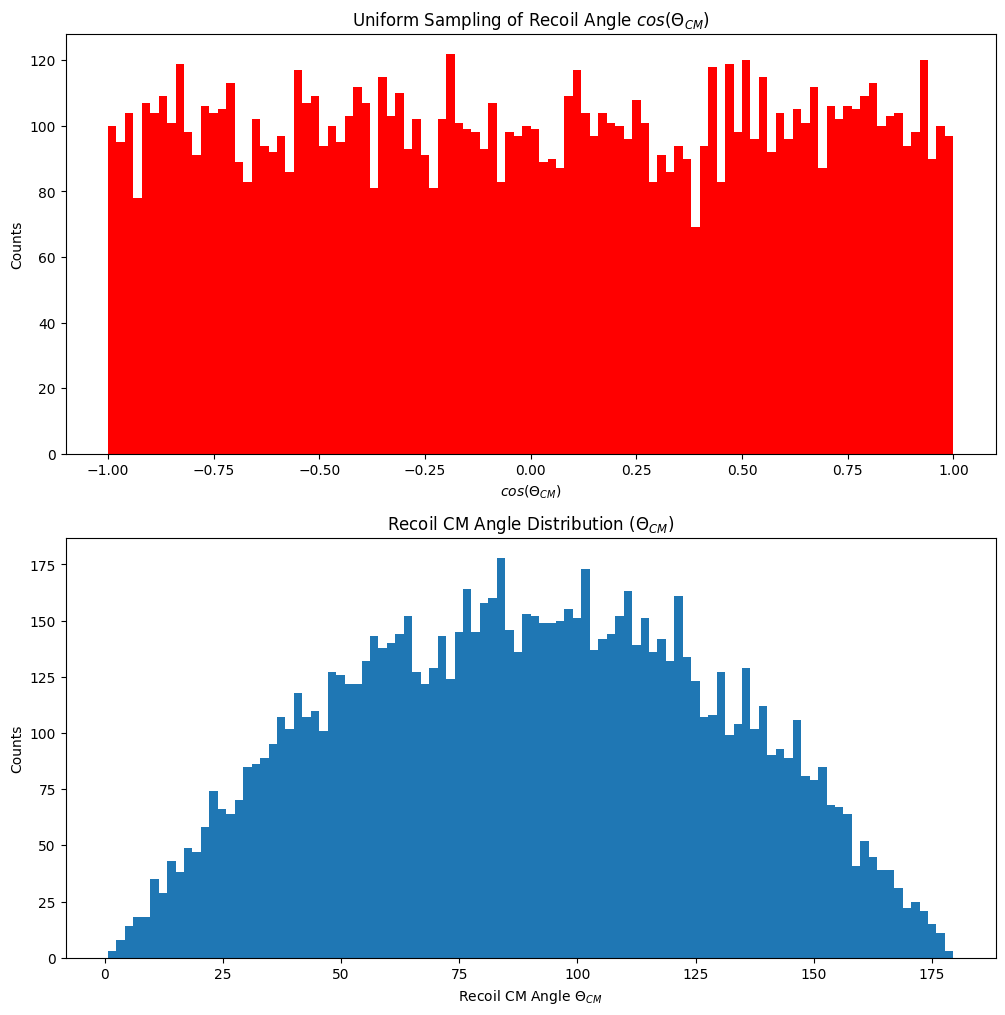

In [138]:
bins = 100
# plt.hist(Thetalab_t, bins = bins)
fig, ax = plt.subplots(2, figsize=(12, 12))

# Monte Carlo draws isotropic samples (uniform in cos(ThetaCM))
ax[0].hist(np.cos(np.deg2rad(ThetaCM_recoil)), bins = bins, color = 'red')
ax[0].set_title(r"Uniform Sampling of Recoil Angle $cos(\Theta_{CM})$")
ax[0].set_xlabel(r"$cos(\Theta_{CM})$")
ax[0].set_ylabel("Counts")
ax[1].hist(ThetaCM_recoil, bins = bins)

ax[1].set_title(r"Recoil CM Angle Distribution $(\Theta_{CM})$")
ax[1].set_xlabel(r"Recoil CM Angle $\Theta_{CM}$")
ax[1].set_ylabel("Counts")



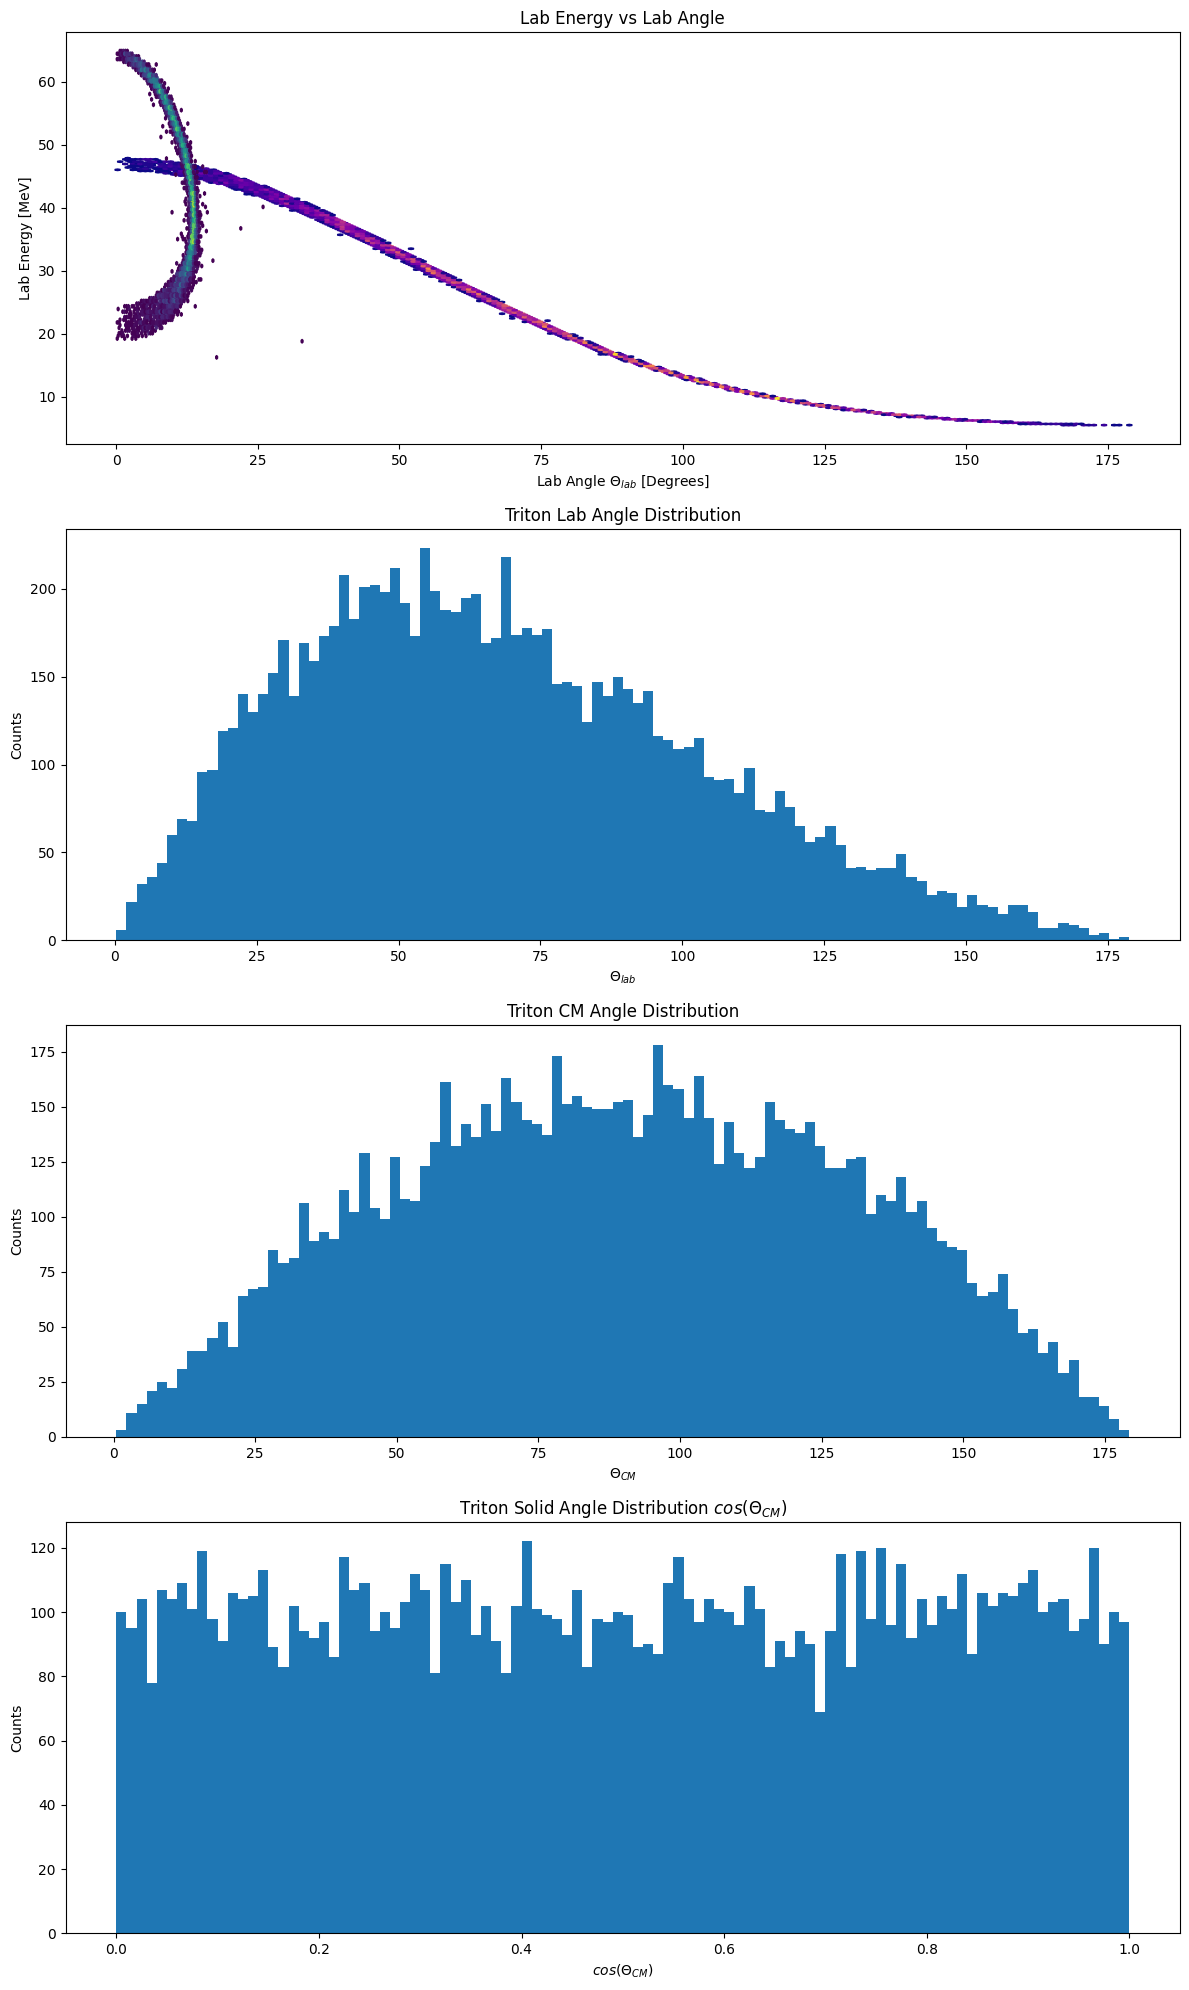

In [156]:
# Checking
fig, ax = plt.subplots(4, figsize=(12, 20))
ax[0].hexbin(Thetalab_t, E_t, gridsize=200, cmap="plasma", mincnt=1, label="Triton")
ax[0].set_xlabel(r"Lab Angle $\Theta_{lab}$ [Degrees]")
ax[0].set_ylabel("Lab Energy [MeV]")
ax[0].set_title("Lab Energy vs Lab Angle")
ax[0].hexbin(Thetalab_recoil, E_recoil, mincnt=1, label="Recoil")
counts, edges, patches = ax[1].hist(Thetalab_t, bins = bins)
ax[1].set_xlabel(r"$\Theta_{lab}$")
ax[1].set_ylabel("Counts")
ax[1].set_title("Triton Lab Angle Distribution")
ax[2].hist(ThetaCM_t, bins = bins)
ax[2].set_xlabel(r"$\Theta_{CM}$")
ax[2].set_ylabel("Counts")
ax[2].set_title("Triton CM Angle Distribution")
ax[3].hist((1 - np.cos(np.deg2rad(ThetaCM_t)))/2, bins = bins)
ax[3].set_xlabel(r"$cos(\Theta_{CM})$")
ax[3].set_ylabel("Counts")
ax[3].set_title(r"Triton Solid Angle Distribution $cos(\Theta_{CM})$")
plt.tight_layout()


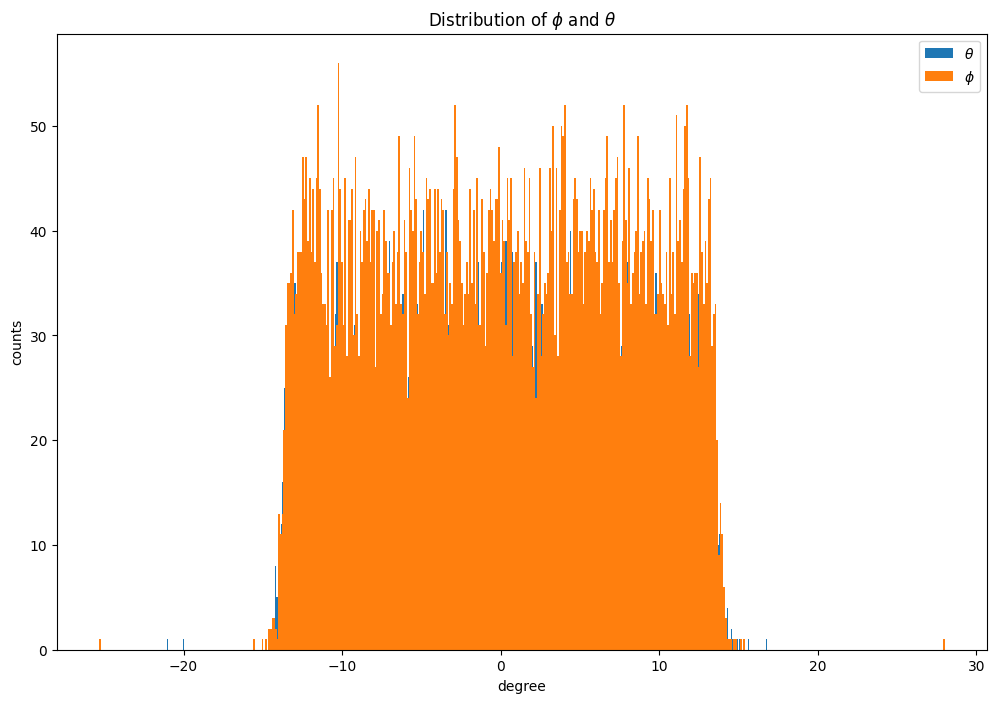

In [ ]:
Theta = np.deg2rad(post_target_reaction[:, 1])
Phi = np.deg2rad(post_target_reaction[:, -1])
# ux = post_target_reaction[:, 2]
# uy = post_target_reaction[:, 3]
# uz = post_target_reaction[:, 4]
bins = 500
# Phi = np.arctan2(uy, ux)
# plt.hist(np.arctan2(uy, ux), bins = 100)
plt.figure(figsize=(12, 8))
# theta = np.arctan2(np.tan(Theta) * np.cos(Phi), np.cos(Theta))  # in radians 
# phi = np.arctan2(np.tan(Theta) * np.sin(Phi), np.cos(Theta))    # in radians 
theta = np.arctan(np.tan(Theta) * np.cos(Phi))
phi = np.arctan(np.tan(Theta) * np.sin(Phi))
# plt.hist(Theta, bins = 100)
# plt.hist(Phi, bins = 100)
plt.hist(np.rad2deg(theta), bins = bins, label = r"$\theta$")
plt.hist(np.rad2deg(phi), bins = bins, label = r"$\phi$")
plt.xlabel("degree")
plt.ylabel("counts")
plt.title(r"Distribution of $\phi$ and $\theta$")
plt.legend()


Text(0, 0.5, 'Kinetic Energy')

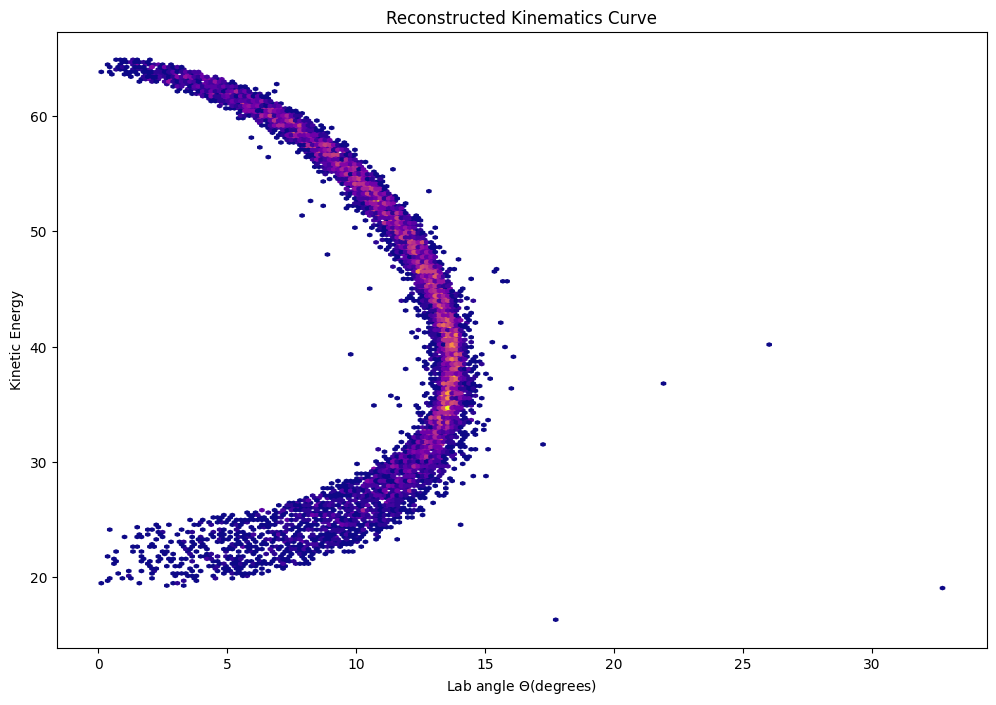

In [102]:
Theta_rec = np.rad2deg(np.arctan(np.sqrt(np.tan(theta)**2 + np.tan(phi)**2)))
# Theta_rec = np.rad2deg(np.arctan2(np.sqrt(ux**2+uy**2), uz))
# plt.hexbin(np.rad2deg(theta), np.rad2deg(phi), gridsize=200, cmap="plasma", mincnt=1, label="Ex = 0 MeV")
plt.figure(figsize=(12, 8))
plt.hexbin(Theta_rec, Ekin_ptr, gridsize=200, cmap="plasma", mincnt=1, label="Ex = 0 MeV")
plt.title("Reconstructed Kinematics Curve")
plt.xlabel(r"Lab angle $\Theta$(degrees)")
plt.ylabel("Kinetic Energy")

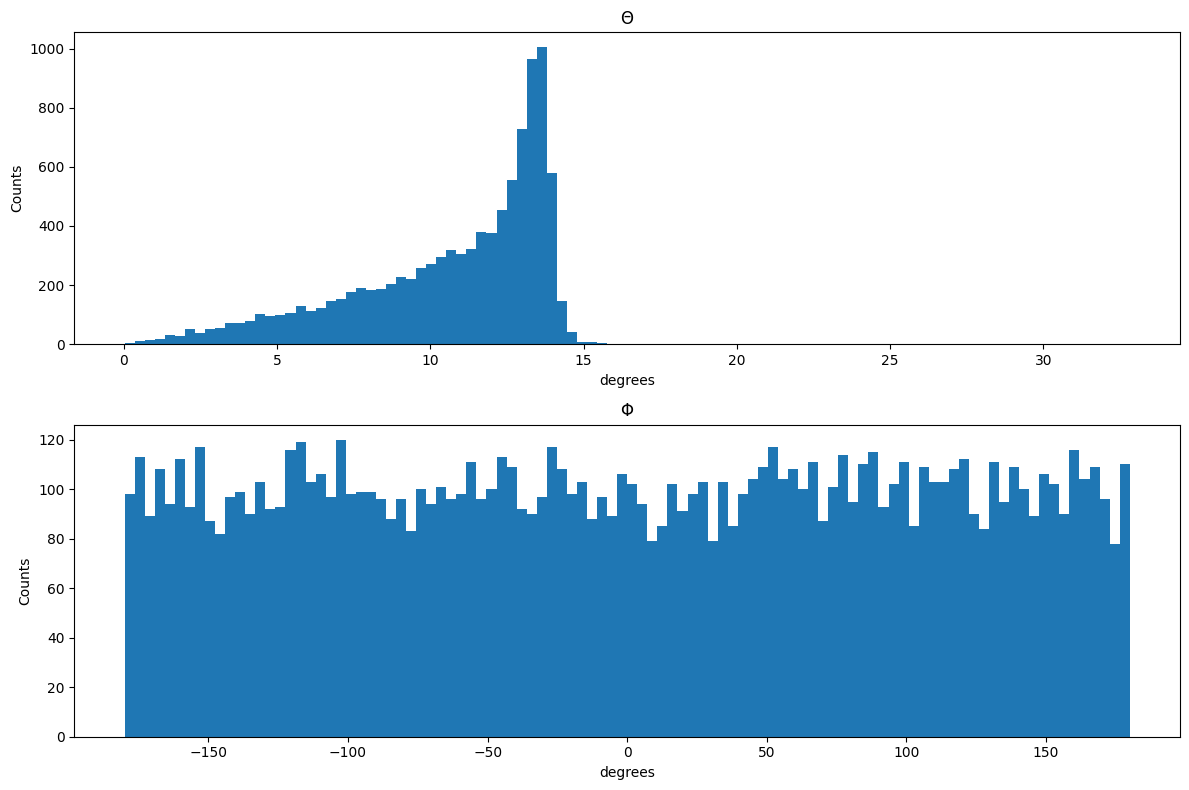

In [103]:
fig, ax = plt.subplots(2, figsize=(12, 8))


ax[0].hist(np.rad2deg(Theta), bins = 100)
ax[1].hist(np.rad2deg(Phi), bins = 100)
ax[0].set_title(r"$\Theta$")
ax[1].set_title(r"$\Phi$")
ax[0].set_xlabel("degrees")
ax[1].set_xlabel("degrees")
ax[0].set_ylabel("Counts")
ax[1].set_ylabel("Counts")
plt.tight_layout()

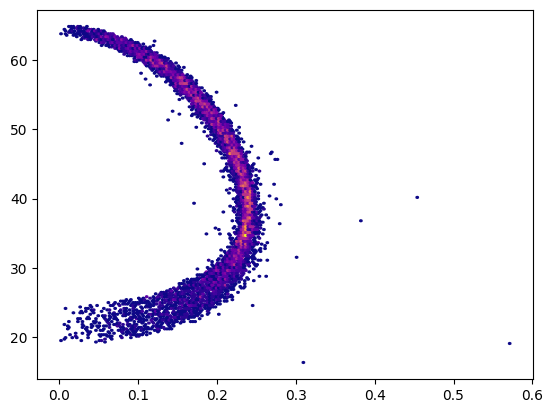

In [104]:
Theta_rec = np.rad2deg(np.arctan(np.sqrt(np.tan(theta)**2 + np.tan(phi)**2)))
plt.hexbin(Theta, Ekin_ptr, gridsize=200, cmap="plasma", mincnt=1, label="Ex = 0 MeV")

$$\theta = arctan(tan\Theta cos(\Phi))$$
$$\phi = arctan(tan\Theta sin(\Phi))$$

$$\Phi = arctan(tan(\phi) / tan(\theta)) $$
$$ tan^2 \Theta = tan^2 \theta + tan^2 \phi $$
$$ \theta = arctan(\sqrt {\frac {tan^2\Theta}{1 + tan^2 \Phi}}) $$
$$ \phi = arctan(tan\Phi \sqrt{\frac{tan^2(\Theta)}{1 + tan^2\Phi}})$$






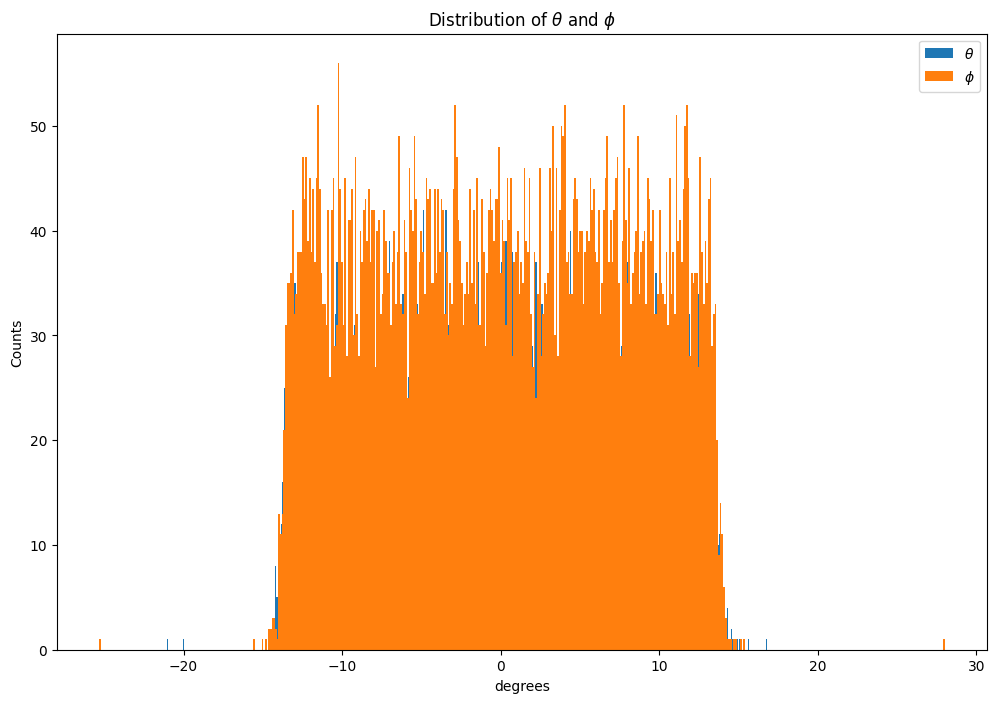

In [105]:
plt.figure(figsize=(12, 8))

plt.hist(np.rad2deg(theta), bins = 500, label = r"$\theta$")
plt.hist(np.rad2deg(phi), bins = 500, label = r"$\phi$")
plt.xlabel("degrees")
plt.ylabel("Counts")
plt.title(r"Distribution of $\theta$ and $\phi$")
plt.legend()
# Phi_rec = np.atan2(np.tan(phi), np.tan(theta))
# plt.hist(Phi_rec, bins = 100)

# Theta_rec = np.arctan(np.sqrt(np.tan(theta)**2 + np.tan(phi)**2))
# plt.hist(Theta_rec, bins = 100)

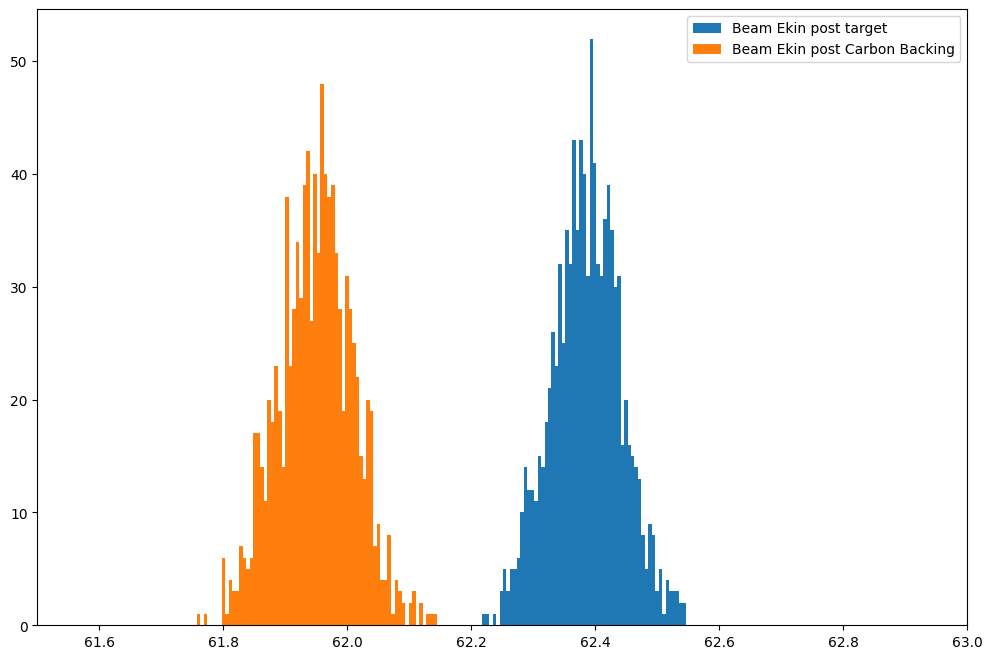

In [ ]:
plt.figure(figsize=(12, 8))
x, y, z = plt.hist(Ekin_ptb, bins = 700, label="Beam Ekin post target")
plt.hist(Ekin_pd1b, bins=700, label="Beam Ekin post Carbon Backing")
# plt.hist(Ekin_ptb_6, bins = 700, label = "Beam Ekin post target (Ex = 10.95MeV)")
# plt.hist(Ekin_pd1b_10pt95, bins = 700, label = "Beam Ekin post Carbon Backing (Ex = 10.95MeV)")
plt.xlim(61.5, 63)
plt.legend()